# J. Modelo y experimentación

Este notebook ejecuta de forma independiente el pipeline de modelado para **Adult / Census Income**. Compara un baseline y varios algoritmos mediante validación cruzada, selecciona el modelo sin consultar el conjunto de prueba, ajusta el umbral con predicciones *out-of-fold*, evalúa una sola vez en test, analiza el desempeño por sexo y registra los experimentos y el modelo seleccionado en MLflow.

> No es necesario ejecutar previamente `Proyecto_Final_Mod6.ipynb`. El pipeline de modelado invoca internamente la ingesta, validación, limpieza y separación de datos definidas en `src/pipeline_datos.py`.

## 1. Preparación e importaciones

El notebook debe abrirse desde la carpeta raíz del proyecto para conservar las rutas reproducibles.

In [36]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    raise FileNotFoundError('Abra este notebook desde la carpeta raíz del proyecto.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.pipeline_datos import PipelineConfig
from src.pipeline_ML import MLPipelineConfig, ejecutar_pipeline_ml

DATA_OUTPUT_DIR = PROJECT_ROOT / 'resultado_pipeline'
ML_OUTPUT_DIR = DATA_OUTPUT_DIR / 'modelo'
RAW_DATA_PATH = DATA_OUTPUT_DIR / 'adult_raw.csv'

print(f'Proyecto: {PROJECT_ROOT}')
print(f'Datos raw disponibles: {RAW_DATA_PATH.exists()}')

Proyecto: c:\Users\c3283\Desktop\INCOEX\proyecto de nuevo
Datos raw disponibles: True


## 2. Configuración reproducible

Se fija la semilla aleatoria, se emplean cinco particiones estratificadas y se selecciona el modelo por **Average Precision**, una métrica apropiada cuando la clase positiva es minoritaria. El umbral final se optimiza por F1 usando únicamente predicciones de entrenamiento *out-of-fold*.

In [37]:
configuracion_datos = PipelineConfig(
    test_size=0.20,
    random_state=42,
    min_category_frequency=100,
    minimum_rows=30_000,
)

configuracion_ml = MLPipelineConfig(
    random_state=42,
    cv_folds=5,
    primary_metric='average_precision',
    threshold_objective='f1',
    minimum_precision=None,
    experiment_name='adult_income_classification',
    tracking_uri='sqlite:///mlflow.db',
    registered_model_name='adult-income-classifier',
)

display(configuracion_datos)
display(configuracion_ml)

PipelineConfig(test_size=0.2, random_state=42, min_category_frequency=100, minimum_rows=30000)

MLPipelineConfig(random_state=42, cv_folds=5, primary_metric='average_precision', threshold_objective='f1', minimum_precision=None, experiment_name='adult_income_classification', tracking_uri='sqlite:///mlflow.db', registered_model_name='adult-income-classifier')

## 3. Entrenamiento, comparación y registro

Se comparan `DummyClassifier` (baseline), regresión logística, Random Forest e HistGradientBoosting. Cada candidato se evalúa con las mismas particiones y las mismas transformaciones para evitar *data leakage*. Esta celda puede tardar varios minutos.

In [38]:
resultado_modelo = ejecutar_pipeline_ml(
    data_output_dir=DATA_OUTPUT_DIR,
    ml_output_dir=ML_OUTPUT_DIR,
    raw_path=RAW_DATA_PATH if RAW_DATA_PATH.exists() else None,
    data_config=configuracion_datos,
    ml_config=configuracion_ml,
    enable_mlflow=True,
)

print('Pipeline de modelado ejecutado correctamente.')
print(f'Resultados guardados en: {resultado_modelo["output_dir"].resolve()}')

c:\Users\c3283\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\c3283\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\c3283\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

Pipeline de modelado ejecutado correctamente.
Resultados guardados en: C:\Users\c3283\Desktop\INCOEX\proyecto de nuevo\resultado_pipeline\modelo


Registered model 'adult-income-classifier' already exists. Creating a new version of this model...
Created version '7' of model 'adult-income-classifier'.


In [39]:
ids_runs = resultado_modelo["manifest"]["mlflow_run_ids"]

print("Experimentos registrados:")

for nombre, run_id in ids_runs.items():
    print(f"{nombre}: {run_id}")

Experimentos registrados:
hist_gradient_boosting: b767f6c4b4b2442384538a58ce0eab2b
random_forest: fcaab2053cc84971a2f1b21f4a30cf8a
logistic_regression: 337ab731e3044af8a10fa09850ecb68f
dummy_baseline: da1380a3ef5f4456b3a767ab23118925
selected_model: 4c5d5fd38b95454caf17f1da24795e1d


## 4. Comparación mediante validación cruzada

La selección se realiza por el promedio de Average Precision en validación cruzada. La desviación estándar permite observar la estabilidad entre particiones. El test permanece aislado durante esta decisión.

In [40]:
comparacion = resultado_modelo['comparison'].copy()
columnas_resumen = [
    'algorithm',
    'cv_average_precision_mean', 'cv_average_precision_std',
    'cv_roc_auc_mean', 'cv_f1_mean',
    'cv_precision_mean', 'cv_recall_mean',
    'cv_balanced_accuracy_mean', 'fit_time_mean_seconds',
]
display(comparacion[columnas_resumen].round(4))

modelo_seleccionado = resultado_modelo['manifest']['selected_algorithm']
print(f'Modelo seleccionado: {modelo_seleccionado}')
print('Criterio de selección: mayor Average Precision promedio en validación cruzada.')

,algorithm,cv_average_precision_mean,cv_average_precision_std,cv_roc_auc_mean,cv_f1_mean,cv_precision_mean,cv_recall_mean,cv_balanced_accuracy_mean,fit_time_mean_seconds
0,hist_gradient_boosting,0.8264,0.0097,0.9278,0.7145,0.6080,0.8665,0.8453,2.1704
1,random_forest,0.8006,0.0098,0.9173,0.7015,0.6016,0.8413,0.8329,3.8397
2,logistic_regression,0.7713,0.0114,0.9082,0.6823,0.5704,0.8487,0.8237,1.0322
3,dummy_baseline,0.2394,0.0000,0.5000,0.0000,0.0000,0.0000,0.5000,0.5875


Modelo seleccionado: hist_gradient_boosting
Criterio de selección: mayor Average Precision promedio en validación cruzada.


## 5. Selección del umbral

El umbral no se ajusta sobre test. Se calcula con probabilidades *out-of-fold* del conjunto de entrenamiento para maximizar F1 y mantener una evaluación final imparcial.

In [41]:
tabla_umbral = pd.read_csv(ML_OUTPUT_DIR / 'busqueda_umbral_oof.csv')
umbral = resultado_modelo['threshold']
mejor_fila = tabla_umbral.loc[(tabla_umbral['threshold'] - umbral).abs().idxmin()]

display(mejor_fila.to_frame('resultado').round(4))
print(f'Umbral seleccionado: {umbral:.3f}')

,resultado
threshold,0.6450
precision,0.6885
recall,0.7676
f1,0.7259


Umbral seleccionado: 0.645


## 6. Evaluación final en test

El conjunto de prueba se utiliza una sola vez después de seleccionar el algoritmo y el umbral. Se reportan métricas adecuadas para clasificación desbalanceada, no solamente accuracy.

,valor
threshold,0.6450
precision,0.6848
recall,0.7868
f1,0.7323
roc_auc,0.9332
average_precision,0.8407
balanced_accuracy,0.8364


,pred_0,pred_1
real_0,6576,846
real_1,498,1838


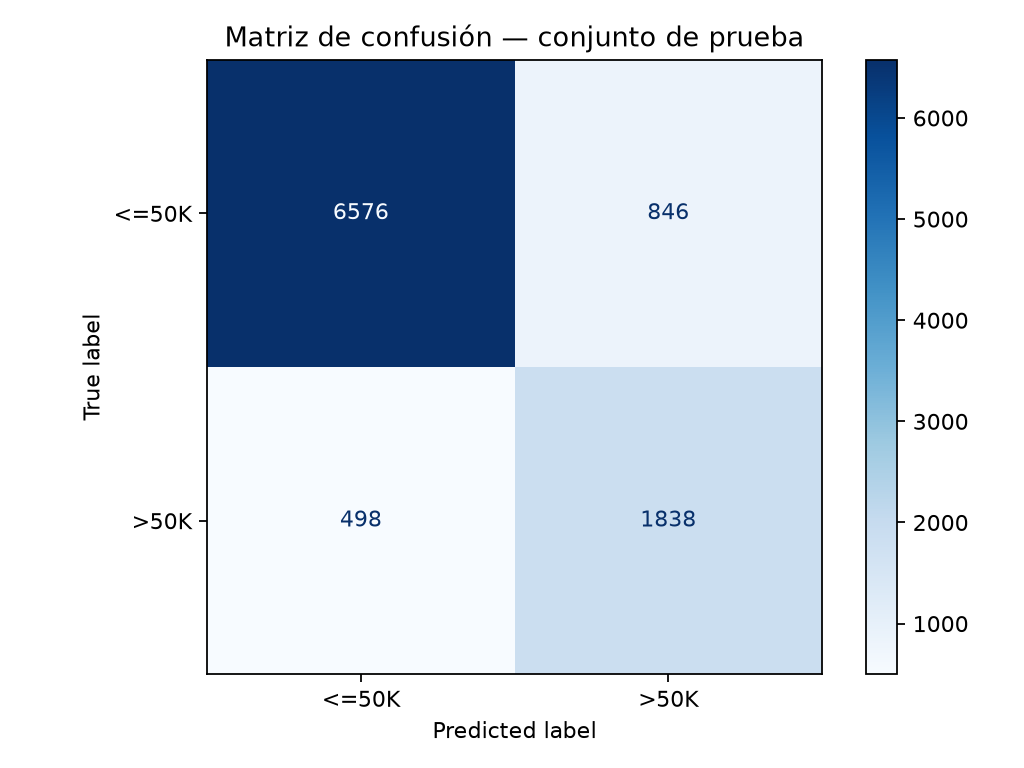

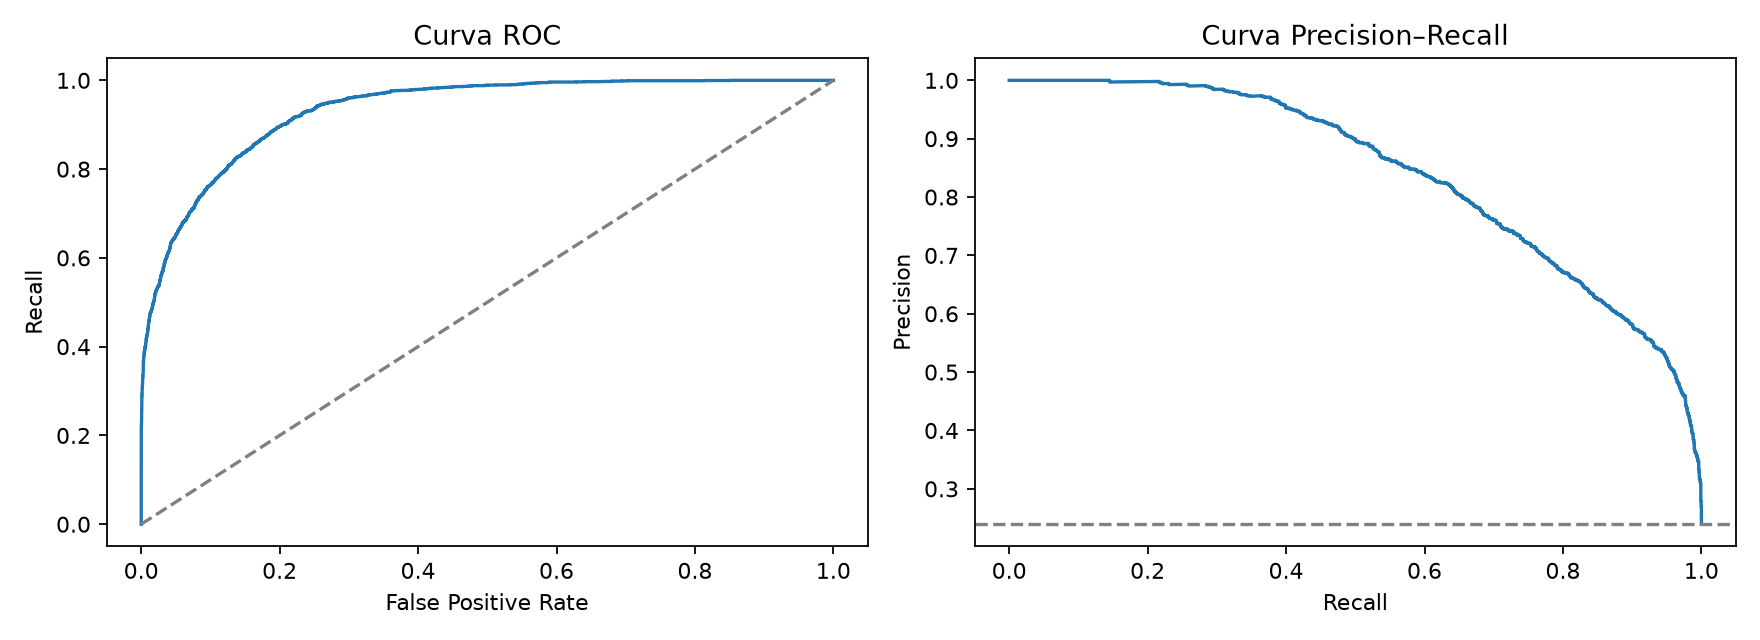

In [42]:
metricas_test = pd.Series(resultado_modelo['metrics'], name='valor').to_frame()
display(metricas_test.round(4))

matriz_confusion = pd.read_csv(ML_OUTPUT_DIR / 'matriz_confusion.csv', index_col=0)
display(matriz_confusion)
display(Image(filename=str(ML_OUTPUT_DIR / 'matriz_confusion.png')))
display(Image(filename=str(ML_OUTPUT_DIR / 'curvas_roc_pr.png')))

## 7. Auditoría por subgrupos

Debido al contexto del dataset Adult, se comparan resultados entre los subgrupos de `sex`. Las diferencias observadas deben interpretarse como señales para auditoría; por sí solas no demuestran causalidad ni garantizan equidad.

In [43]:
metricas_subgrupos = resultado_modelo['subgroup_metrics'].copy()
display(metricas_subgrupos.round(4))

metricas_comparables = ['precision', 'recall', 'f1', 'false_positive_rate', 'average_precision']
brechas = (
    metricas_subgrupos.set_index('group')[metricas_comparables].max()
    - metricas_subgrupos.set_index('group')[metricas_comparables].min()
).rename('brecha_absoluta')
display(brechas.to_frame().round(4))

,group_column,group,n,actual_positive_rate,predicted_positive_rate,precision,recall,f1,false_positive_rate,average_precision
0,sex,Female,3326,0.1152,0.0989,0.769,0.6606,0.7107,0.0258,0.8032
1,sex,Male,6432,0.3036,0.3661,0.673,0.8116,0.7358,0.1719,0.8488


,brecha_absoluta
precision,0.0960
recall,0.1510
f1,0.0252
false_positive_rate,0.1461
average_precision,0.0456


## 8. Trazabilidad y artefactos de MLflow

Cada candidato registra algoritmo, hiperparámetros, conjunto de features, semilla, versión de datos y métricas de validación. El run final registra las métricas de test, gráficos, configuración, predicciones, matriz de confusión y el pipeline completo en el Model Registry.

In [44]:
manifiesto = resultado_modelo['manifest']

resumen_trazabilidad = pd.Series({
    'algoritmo_seleccionado': manifiesto['selected_algorithm'],
    'métrica_de_selección': manifiesto['selection_metric'],
    'umbral_seleccionado': manifiesto['selected_threshold'],
    'versión_de_datos_sha256': manifiesto['data_version_sha256'],
    'fecha_utc': manifiesto['created_at_utc'],
}, name='valor').to_frame()
display(resumen_trazabilidad)

runs_mlflow = pd.Series(manifiesto['mlflow_run_ids'], name='run_id').to_frame()
display(runs_mlflow)

artefactos = pd.DataFrame({'archivo': manifiesto['artifacts']})
artefactos['existe'] = artefactos['archivo'].map(lambda nombre: (ML_OUTPUT_DIR / nombre).exists())
display(artefactos)
assert artefactos['existe'].all()

,valor
algoritmo_seleccionado,hist_gradient_boosting
métrica_de_selección,average_precision
umbral_seleccionado,0.645
versión_de_datos_sha256,7dc84f5b49c0db8850e232cc6d0c73575aeea05c84e61e...
fecha_utc,2026-08-27T07:10:50.815269+00:00


,run_id
hist_gradient_boosting,b767f6c4b4b2442384538a58ce0eab2b
random_forest,fcaab2053cc84971a2f1b21f4a30cf8a
logistic_regression,337ab731e3044af8a10fa09850ecb68f
dummy_baseline,da1380a3ef5f4456b3a767ab23118925
selected_model,4c5d5fd38b95454caf17f1da24795e1d


,archivo,existe
0,busqueda_umbral_oof.csv,True
1,comparacion_modelos_cv.csv,True
2,configuracion_ml.json,True
3,curvas_roc_pr.png,True
4,manifest_modelo.json,True
5,matriz_confusion.csv,True
6,matriz_confusion.png,True
7,metricas_subgrupos_sex.csv,True
8,metricas_test.json,True
9,modelo_clasificacion.joblib,True


## 9. Abrir la interfaz de MLflow

Desde una terminal ubicada en la raíz del proyecto, ejecute:

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

Después abra `http://127.0.0.1:5000`. Allí se pueden comparar los runs y revisar la versión registrada de `adult-income-classifier`.

## 10. Conclusión reproducible

La decisión final debe sustentarse en los resultados generados durante la ejecución: desempeño de validación frente al baseline, estabilidad entre folds, métricas finales en test y diferencias entre subgrupos. El archivo `manifest_modelo.json` conserva el algoritmo, configuraciones, versión de los datos, métricas e identificadores de MLflow necesarios para auditar el resultado.